In [11]:
import numpy as np
import matplotlib.pyplot as plt

def compute_mean_rate_1D(
    flux_file: str,
    dt_ps: float = 5.0,
    window_time: float = 5e-10
):

    # ------------------------------------------------------------
    # Read data
    # ------------------------------------------------------------
    data = []
    with open(flux_file, "r") as f:
        for line in f:
            if not line.strip().startswith("Iteration"):
                continue
            try:
                parts = [p.strip() for p in line.split(",")]
                it  = int(parts[0].split()[1])
                wt  = float(parts[2].split(":")[1])
                data.append([it, wt])
            except Exception:
                continue

    if not data:
        raise ValueError("No valid lines found in flux file")

    data = np.asarray(data, dtype=float)
    its     = data[:, 0].astype(int)
    weights = data[:, 1]
    # ------------------------------------------------------------
    # Normalize iteration indices
    # ------------------------------------------------------------
    min_iter = its.min()
    iter_idx = its - min_iter
    n_iters  = iter_idx.max() + 1

    # Use weights from the pre-filtered flux files.
    effective_weights = weights.copy()
    # ------------------------------------------------------------
    # Aggregate flux per iteration
    # ------------------------------------------------------------
    flux = np.bincount(
        iter_idx,
        weights=effective_weights,
        minlength=n_iters
    )

    # ------------------------------------------------------------
    # Time scaling + running mean
    # ------------------------------------------------------------
    tau = dt_ps * 1e-12
    window_frames = max(1, int(window_time / tau))

    rates = np.zeros(len(flux))
    for i in range(len(flux)):
        start = max(0, i - window_frames + 1)
        rates[i] = np.mean(flux[start : i + 1]) / tau

    time_ns = (np.arange(n_iters) + 1) * tau * 1e9

    return time_ns, rates


def bayesian_bootstrap_mean_ci(values, n_boot=20000, ci=0.95, random_state=0):
    """
    Bayesian bootstrap for mean and credible interval.

    values: array-like, shape (n_samples,)
    """
    rng = np.random.default_rng(random_state)
    n = len(values)

    # Dirichlet weights
    weights = rng.dirichlet(np.ones(n), size=n_boot)

    # Posterior samples of the mean
    means = weights @ values

    mean_est = means.mean()
    alpha = (1 - ci) / 2
    lo, hi = np.quantile(means, [alpha, 1 - alpha])

    return mean_est, lo, hi
def mean_ci_from_replicas(t_ref, lts, lrs, npts=2500):
    """
    Interpolate replicas onto a common time grid and compute
    Bayesian bootstrap mean and CI.
    """
    t_common = t_ref[:npts]

    interp_vals = [
        np.interp(t_common, lt, lr) for lt, lr in zip(lts[1:], lrs[1:])
    ]

    mean = np.zeros_like(t_common)
    lo   = np.zeros_like(t_common)
    hi   = np.zeros_like(t_common)

    for i in range(len(t_common)):
        vals = np.array([lrs[0][i]] + [v[i] for v in interp_vals])
        m, l, h = bayesian_bootstrap_mean_ci(vals)
        mean[i], lo[i], hi[i] = m, l, h

    return t_common, mean, lo, hi

In [12]:
path11 = "data/assets/3PTB/flux_files/3ptb_flux_major_1.txt"
path12 = "data/assets/3PTB/flux_files/3ptb_flux_major_2.txt"
path13 = "data/assets/3PTB/flux_files/3ptb_flux_major_3.txt"

path21 = "data/assets/3PTB/flux_files/3ptb_flux_path2_1.txt"
path22 = "data/assets/3PTB/flux_files/3ptb_flux_path2_2.txt"
path23 = "data/assets/3PTB/flux_files/3ptb_flux_path2_3.txt"

path31 = "data/assets/3PTB/flux_files/3ptb_flux_path3_1.txt"
path32 = "data/assets/3PTB/flux_files/3ptb_flux_path3_2.txt"
path33 = "data/assets/3PTB/flux_files/3ptb_flux_path3_3.txt"

In [13]:
# ==========================
# PATH-SPECIFIC COLORS
# ==========================
path4_color = "#E69F00"   # orange
path2_color = "#009E73"   # green
path3_color = "#0072B2"   # bluish

path1_color = "#1f77b4"  # blue
path2_color = "#d62728"  # red
path3_color = "#2ca02c"  # green


# Path 1
t1, r1 = compute_mean_rate_1D(path11, dt_ps = 20, window_time = 2.5e-9)
t2, r2 = compute_mean_rate_1D(path12, dt_ps = 20, window_time = 2.5e-9)
t3, r3 = compute_mean_rate_1D(path13, dt_ps = 20, window_time = 2.5e-9)

# Path 2
t4, r4 = compute_mean_rate_1D(path21, dt_ps = 20, window_time = 2.5e-9)

t5, r5 = compute_mean_rate_1D(path22, dt_ps = 20, window_time = 2.5e-9)

t6, r6 = compute_mean_rate_1D(path23, dt_ps = 20, window_time = 2.5e-9)

# Path 3

t7, r7 = compute_mean_rate_1D(path31, dt_ps = 20, window_time = 2.5e-9)

t8, r8 = compute_mean_rate_1D(path32, dt_ps = 20, window_time = 2.5e-9)

t9, r9 = compute_mean_rate_1D(path33, dt_ps = 20, window_time = 2.5e-9)


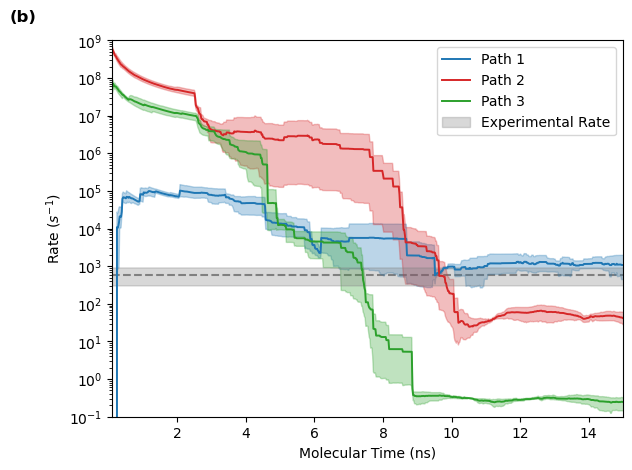

In [18]:
fig, ax1  = plt.subplots()

# =========================
# TOP PANEL: RATE vs TIME
# =========================

t, m, lo, hi = mean_ci_from_replicas(
    t1, [t1, t2, t3], [r1, r2, r3]
)
ax1.plot(t, m, color=path1_color, lw=1.4, label="Path 1")
ax1.fill_between(t, lo, hi, color=path1_color, alpha=0.3)

t, m, lo, hi = mean_ci_from_replicas(
    t4, [t4, t5, t6], [r4, r5, r6]
)
ax1.plot(t, m, color=path2_color, lw=1.4, label="Path 2")
ax1.fill_between(t, lo, hi, color=path2_color, alpha=0.3)

t, m, lo, hi = mean_ci_from_replicas(
    t7, [t7, t8, t9], [r7, r8, r9]
)
ax1.plot(t, m, color=path3_color, lw=1.4, label="Path 3")
ax1.fill_between(t, lo, hi, color=path3_color, alpha=0.3)

ax1.set_yscale("log")
ax1.axhline(600, ls="--", color="gray", zorder=-1)
ax1.fill_between(
    t, 300, 900,
    color="gray",
    alpha=0.3,
    label="Experimental Rate"
)

ax1.set_xlim(0.10, 15)
ax1.set_ylim(0.1, 1e9)
ax1.set_ylabel(r"Rate ($s^{-1}$)")
ax1.legend()


ax1.set_xlabel("Molecular Time (ns)")
ax1.text(-0.2, 1.05, "(b)", transform=ax1.transAxes, fontsize=12, fontweight="bold")

fig.tight_layout()
plt.show()

In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
import MDAnalysis as mda
import joblib
from MDAnalysis.analysis.distances import distance_array, calc_bonds

In [5]:
conf = "data/assets/3PTB/md.gro"
trajs = glob.glob("data/assets/3PTB/protein_ligand/*xtc")
ref = mda.Universe(conf)

In [4]:
def make_conf(u, model_file):
    # Define atom selections based on command-line arguments
    protein_selection_str = 'around 20.0 resname BEN'
    ligand_selection_str = 'resname BEN and not type H'

    protein_nearby_indices = u.select_atoms(protein_selection_str).select_atoms("name CA").indices
    ligand_indices = u.select_atoms(ligand_selection_str).indices

    print(f"Found {len(protein_nearby_indices)} protein atoms and {len(ligand_indices)} ligand atoms.")

    # Load the pre-trained PCA model
    model = joblib.load(model_file)
    print(f"Loaded PCA model from '{model_file}'.")

    # Prepare arguments for the projection function
    return {
        "protein_indices": protein_nearby_indices,
        "ligand_indices": ligand_indices,
        "model": model
    }


def projection(positions, **kwargs):
    """
    Projects the atomic positions onto the principal components.

    This function calculates the distance features between the protein and ligand,
    and then uses a pre-trained PCA model to reduce the dimensionality.

    Args:
        positions (np.ndarray): Array of atomic positions from the simulation frame.
        **kwargs: Keyword arguments containing:
            protein_indices (np.ndarray): Indices of the protein atoms.
            ligand_indices (np.ndarray): Indices of the ligand atoms.
            model (object): The loaded PCA model object.

    Returns:
        tuple: A tuple containing:
            - The first 4 principal components of the transformed features.
            - The distance between the center of mass of the protein and ligand.
            - The minimum distance between any protein and ligand atom.
    """
    protein_indices = kwargs.get('protein_indices')
    ligand_indices = kwargs.get('ligand_indices')
    model = kwargs.get('model')

    if protein_indices is None or ligand_indices is None or model is None:
        raise ValueError("Missing required arguments in projection function: protein_indices, ligand_indices, or model.")

    # Extract positions for protein and ligand
    prot_pos = positions[protein_indices]
    lig_pos = positions[ligand_indices]

    # Calculate pairwise distances and flatten to create a feature vector
    my_distance = distance_array(prot_pos, lig_pos)
    feat = my_distance.ravel()

    # Calculate center of mass distance
    prot_com = prot_pos.mean(axis=0)
    lig_com = lig_pos.mean(axis=0)
    com_dist = calc_bonds(prot_com, lig_com)

    # Transform features using the PCA model and return key metrics
    # The original code returns the first 4 components, so we slice with [:4]
    transformed_features = model.transform(feat.reshape(1, -1))
    return transformed_features[0], com_dist, np.min(my_distance)

kwargs = make_conf(ref, "data/assets/3PTB/pca_minmax_pipeline.pkl")
def getPC(u):
    pc_list = []
    for _ in u.trajectory:
        pc_list.append(projection(u.atoms.positions, **kwargs)[0])
    return np.array(pc_list)


Found 163 protein atoms and 9 ligand atoms.
Loaded PCA model from 'data/assets/3PTB/pca_minmax_pipeline.pkl'.


/home/dm/Soft/miniconda3/envs/torch311/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dm/Soft/miniconda3/envs/torch311/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dm/Soft/miniconda3/envs/torch311/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7

In [6]:
trajectories = []
conf = "data/assets/3PTB/protein_ligand.pdb"
for traj in trajs:
    u = mda.Universe(conf, traj)
    pc = getPC(u)
    trajectories.append(pc)

/home/dm/Soft/miniconda3/envs/torch311/lib/python3.11/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/home/dm/Soft/miniconda3/envs/torch311/lib/python3.11/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/home/dm/Soft/miniconda3/envs/torch311/lib/python3.11/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAtt

In [7]:
from sklearn.cluster import AgglomerativeClustering
from dtaidistance import dtw_ndim
def dtw_trajectory_distance(traj1, traj2):
    """
    Calculates the multi-dimensional DTW distance between two trajectories.
    """
    # Using a window can dramatically speed up computation.
    # A 10-20% window is common.
    window_size = int(max(len(traj1), len(traj2)) * 0.2)

    # This is the line you had commented out, but it's the right one
    return dtw_ndim.distance_fast(traj1, traj2, window=window_size)

# --- Compute symmetric distance matrix ---
n = len(trajectories)
D = np.zeros((n, n))

print("Calculating DTW distance matrix...")
for i in range(n):
    for j in range(i + 1, n):
        # DTW is symmetric, so D[i,j] == D[j,i]
        # We only need to calculate it once.
        dist = dtw_trajectory_distance(trajectories[i], trajectories[j])
        D[i, j] = dist
        D[j, i] = dist
print("Matrix calculation complete.")

agg_cluster = AgglomerativeClustering(n_clusters=4,
                                      metric='precomputed',
                                      linkage='average')
labels = agg_cluster.fit_predict(D)

Calculating DTW distance matrix...
Matrix calculation complete.


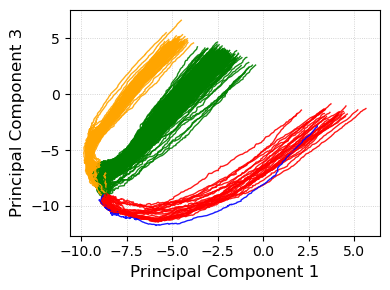

In [9]:
# import seaborn as sns

# Use a modern, distinctive color palette (10 unique hues)
# colors = sns.color_palette("tab10", 10)  # or try "Set2", "husl", "Spectral"
colors = ["red", "green", "blue", "orange", "black"]
# Optional: Different line styles for extra distinction
linestyles = ['-', '-', '-', '-', "-", '-', '-', '-', '-', '-']

plt.figure(figsize=(4, 3))

# Plot each PCA array with distinct color & style
for i, arr in enumerate(trajectories):
    plt.plot(arr[:, 0], arr[:, 2],
             label=f"Run {i+1}",
             color=colors[labels[i]],
             linestyle="-",
             linewidth=1.0,
             alpha=0.9)


# Style adjustments
# plt.title("PCA Projection of 10 Classes", fontsize=14, fontweight='bold')
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 3", fontsize=12)
plt.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)
# plt.legend(ncols=2, frameon=True, loc='best')
plt.tight_layout()
plt.show()